# Validación pipeline BUSI — v8 (producción)


In [1]:
!pip install ultralytics opencv-python pyyaml albumentations --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00


## Importar backup desde Google Drive


In [2]:
from google.colab import drive
import shutil
import os
import zipfile

# 1. Montar Google Drive
print("Montando Google Drive...")
drive.mount('/content/drive')
print("Google Drive montado exitosamente.")

# 2. Definir la ruta de la carpeta específica en Drive
#    *** IMPORTANTE: Cambia esta ruta a la de tu carpeta en Google Drive ***
source_folder_path = '/content/drive/MyDrive/Colab Notebooks/VpC2-TF'

# 3. Definir el nombre del archivo a copiar
#    *** IMPORTANTE: Cambia 'nombre_del_archivo.ext' por el nombre real de tu archivo ***
file_to_copy = 'backup_v8_completo.zip'

# 4. Definir la ruta completa del archivo de origen
source_file_path = os.path.join(source_folder_path, file_to_copy)

# 5. Definir la carpeta de destino en Colab (ej. dentro del entorno de la VM)
destination_folder_path = '/content/'

# Crear la carpeta de destino si no existe
os.makedirs(destination_folder_path, exist_ok=True)

# 6. Definir la ruta completa del archivo de destino
destination_file_path = os.path.join(destination_folder_path, file_to_copy)

# 7. Copiar el archivo
if os.path.exists(source_file_path):
    try:
        shutil.copy(source_file_path, destination_file_path)
        print(f"Archivo '{file_to_copy}' copiado exitosamente de '{source_folder_path}' a '{destination_folder_path}'.")
    except Exception as e:
        print(f"Error al copiar el archivo: {e}")
else:
    print(f"Error: El archivo '{source_file_path}' no existe. Por favor, verifica la ruta y el nombre del archivo.")

# Opcional: Listar el contenido de la carpeta de destino para verificar
print(f"\nContenido de '{destination_folder_path}':")
print(os.listdir(destination_folder_path))

# Descompresión

# 1. Definir la ruta del archivo zip a descomprimir
zip_file_path = '/content/backup_v8_completo.zip'

# 2. Definir la carpeta de destino para la descompresión
destination_folder = '/content/'

# Crear la carpeta de destino si no existe
os.makedirs(destination_folder, exist_ok=True)

# 3. Descomprimir el archivo zip
if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Archivo '{zip_file_path}' descomprimido exitosamente en '{destination_folder}'.")

        # Opcional: Listar el contenido de la carpeta descomprimida para verificar
        print(f"\nContenido de '{destination_folder}':")
        print(os.listdir(destination_folder))

    except zipfile.BadZipFile:
        print(f"Error: El archivo '{zip_file_path}' no es un archivo zip válido o está corrupto.")
    except Exception as e:
        print(f"Error al descomprimir el archivo: {e}")
else:
    print(f"Error: El archivo '{zip_file_path}' no existe. Por favor, verifica la ruta y el nombre del archivo.")



Montando Google Drive...
Mounted at /content/drive
Google Drive montado exitosamente.
Archivo 'backup_v8_completo.zip' copiado exitosamente de '/content/drive/MyDrive/Colab Notebooks/VpC2-TF' a '/content/'.

Contenido de '/content/':
['.config', 'drive', 'backup_v8_completo.zip', 'sample_data']
Archivo '/content/backup_v8_completo.zip' descomprimido exitosamente en '/content/'.

Contenido de '/content/':
['.config', '__MACOSX', 'drive', 'runs', 'backup_v8_completo.zip', 'models_busi_pipeline_v8', 'sample_data']


In [3]:
!rm -rf /content/__MACOSX /content/sample_data
!ls /content/

backup_v8_completo.zip	drive  models_busi_pipeline_v8	runs


## Utilidades de inferencia y evaluación


In [4]:
# ── Librerías ────────────────────────────────────────────────────────────────
import json, random, re, shutil
from collections import Counter, defaultdict
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
from ultralytics import YOLO

# ── Constantes ───────────────────────────────────────────────────────────────
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
CLASS_MAP = {"benign": 0, "malignant": 1}
NEGATIVE_CLASS = "normal"

# ── Seed ─────────────────────────────────────────────────────────────────────
def set_global_seed(seed=42):
    random.seed(seed); np.random.seed(seed)

# ── Filesystem ───────────────────────────────────────────────────────────────
def find_image_files(folder: Path):
    return [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]

def reset_output_root(root: Path):
    if root.exists(): shutil.rmtree(root)
    for sub in ["images/train","images/val","images/test",
                "labels/train","labels/val","labels/test"]:
        (root / sub).mkdir(parents=True, exist_ok=True)

def copy_image(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

def save_image(img, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(dst), img)

def write_label_file(label_path: Path, lines):
    label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(label_path, "w") as f:
        f.write("\n".join(lines) + "\n")

# ── Masks / polygons ─────────────────────────────────────────────────────────
def is_mask_file(path: Path):
    return "_mask" in path.stem.lower()

def get_base_image_id(filename: str):
    return re.sub(r"_mask(?:_\d+)?$", "", Path(filename).stem)

def load_binary_masks(mask_paths):
    masks = []
    for mp in mask_paths:
        m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        masks.append((m > 0).astype(np.uint8) * 255)
    return masks

def extract_union_bbox(masks):
    if not masks: return None
    union = np.maximum.reduce(masks)
    ys, xs = np.where(union > 0)
    if len(xs) == 0: return None
    return xs.min(), ys.min(), xs.max(), ys.max(), union

def normalize_polygon(points, w, h):
    return [c for x,y in points for c in (x/w, y/h)]

def mask_array_to_polygons(mask):
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h,w = mask.shape
    polys = []
    for c in contours:
        if cv2.contourArea(c) < 10: continue
        pts = cv2.approxPolyDP(c, 0.001*cv2.arcLength(c, True), True).reshape(-1,2)
        if len(pts) >= 3:
            polys.append(normalize_polygon(pts, w, h))
    return polys

# ── Manifest ──────────────────────────────────────────────────────────────────
def save_split_manifest(items, output_root: Path, split: str):
    manifest = []
    for s in items:
        ip = s["image_path"]; is_aug = s.get("augmented",False); aug_id = s.get("aug_id",0)
        fn = f"{ip.stem}_aug{aug_id}{ip.suffix}" if is_aug else ip.name
        manifest.append({"split":split,"file_name":fn,"true_class":s["class_name"],
                          "is_augmented":is_aug,"source_image":ip.name,"n_masks":len(s["mask_paths"])})
    with open(output_root/f"{split}_manifest.json","w",encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

def load_manifest(dataset_root, split):
    with open(Path(dataset_root)/f"{split}_manifest.json","r",encoding="utf-8") as f:
        data = json.load(f)
    return {row["file_name"]: row for row in data}

# ── Dataset base ─────────────────────────────────────────────────────────────
def build_samples(input_root: Path):
    samples = defaultdict(list)
    for cls in ["benign","malignant","normal"]:
        img_dir = input_root/cls
        mask_dir = input_root/f"{cls}_mask"
        if not img_dir.exists(): continue

        for img in find_image_files(img_dir):
            base = get_base_image_id(img.name)
            masks = []
            if mask_dir.exists():
                masks = [m for m in mask_dir.iterdir()
                         if base in m.name and is_mask_file(m)]

            samples[cls].append({
                "class_name":cls,
                "image_path":img,
                "mask_paths":masks
            })
    return samples

# ── Split ────────────────────────────────────────────────────────────────────
def three_way_stratified_split(items_by_class, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, seed=42):
    rng = random.Random(seed)
    train, val, test = [], [], []
    for cls_name, items in items_by_class.items():
        items = items[:]; rng.shuffle(items); n = len(items)
        n_train = int(n*train_ratio); n_val = int(n*val_ratio)
        train.extend(items[:n_train]); val.extend(items[n_train:n_train+n_val]); test.extend(items[n_train+n_val:])
    return train, val, test

# ── Balance ──────────────────────────────────────────────────────────────────
def balance_train_items(train_items, class_target_counts=None, copy_paste_prob=0.0, seed=42):
    """
    Balancea los items de train hasta los conteos objetivo por clase.
    Mantiene compatibilidad con la firma extendida usada por convert_dataset_stage2.
    """
    rng = random.Random(seed)
    grouped = defaultdict(list)
    for s in train_items:
        grouped[s["class_name"]].append(s)

    if class_target_counts is None:
        max_n = max(len(v) for v in grouped.values())
        class_target_counts = {cls: max_n for cls in grouped}

    balanced = []
    for cls, items in grouped.items():
        target = class_target_counts.get(cls, len(items))
        cur = items[:]
        rng.shuffle(cur)
        while len(cur) < target:
            cur.append(rng.choice(items))
        balanced.extend(cur[:target])

    print(f"Train antes del balance")
    for cls, items in grouped.items():
        print(f"  {cls}: {len(items)}")
    print(f"  total: {sum(len(v) for v in grouped.values())}")
    print(f"\nTrain balanceado REAL")
    by_cls = defaultdict(list)
    for s in balanced: by_cls[s["class_name"]].append(s)
    for cls, items in by_cls.items():
        print(f"  {cls}: {len(items)}")
    print(f"  total: {len(balanced)}")
    return balanced
def build_class_augmenters():
    return {
        "malignant": A.Compose([A.HorizontalFlip(p=0.5), A.RandomBrightnessContrast(p=0.5)]),
        "benign": A.Compose([A.HorizontalFlip(p=0.4)]),
        "normal": A.Compose([A.HorizontalFlip(p=0.5)]),
    }

def augment_sample_with_masks(image, mask_paths, aug):
    masks = load_binary_masks(mask_paths)
    if not masks:
        return aug(image=image)["image"], []
    t = aug(image=image, masks=masks)
    return t["image"], t["masks"]

# ── Procesado split ──────────────────────────────────────────────────────────
def process_split(items, output_root: Path, split="train"):
    augmenters = build_class_augmenters() if split=="train" else None

    for s in items:
        cls = s["class_name"]
        img = cv2.imread(str(s["image_path"]))

        if split=="train":
            aug = augmenters[cls]
            img, masks = augment_sample_with_masks(img, s["mask_paths"], aug)
        else:
            masks = load_binary_masks(s["mask_paths"])

        out_img = output_root/"images"/split/s["image_path"].name
        out_lbl = output_root/"labels"/split/(s["image_path"].stem+".txt")

        save_image(img, out_img)

        if cls == "normal":
            write_label_file(out_lbl, [])
            continue

        lines=[]
        for m in masks:
            for p in mask_array_to_polygons(m):
                if len(p)>=6:
                    lines.append(f"{CLASS_MAP[cls]} {' '.join(f'{x:.6f}' for x in p)}")

        write_label_file(out_lbl, lines)

# ── Dataset completo ─────────────────────────────────────────────────────────
def convert_dataset(input_root, output_root):
    set_global_seed()
    reset_output_root(output_root)

    samples = build_samples(input_root)
    train,val,test = three_way_stratified_split(samples)

    train = balance_train_items(train)

    for split,items in [("train",train),("val",val),("test",test)]:
        process_split(items, output_root, split)

    with open(output_root/"data.yaml","w") as f:
        yaml.safe_dump({
            "path":".",
            "train":"images/train",
            "val":"images/val",
            "test":"images/test",
            "names":{0:"benign",1:"malignant"}
        }, f)

def convert_dataset_stage1(input_root: Path, output_root: Path,
                           train_ratio=0.70, val_ratio=0.15, test_ratio=0.15,
                           seed=42, yaml_base_path="."):
    """
    Dataset para Etapa 1 — detector binario lesión / normal.

    DISEÑO CORRECTO:
      · clase 0 = lesion  (benign + malignant fusionados, con bbox de la máscara)
      · clase 1 = normal  (con bbox de toda la imagen)

    BALANCE 50/50 FORZADO EN TRAIN:
      El dataset original tiene ~3.7x más lesiones que normales. Si entrenamos
      con esa proporción, el detector aprende que "casi todo es lesión" y no
      desarrolla bien la capacidad de rechazar tejido sano. Forzar 50/50 en train
      garantiza que el modelo aprenda el límite de decisión correctamente.

      Val y test mantienen la proporción natural del dataset para que las
      métricas reflejen el rendimiento real en la distribución clínica.

    AUGMENTACIÓN OFFLINE PARA NORMALES EN TRAIN:
      Como hay menos normales, se augmentan con flip horizontal, pequeñas
      rotaciones y variaciones de brillo hasta igualar el número de lesiones.
    """
    set_global_seed(seed)
    root = output_root
    for sub in ["images/train","images/val","images/test",
                "labels/train","labels/val","labels/test"]:
        (root/sub).mkdir(parents=True, exist_ok=True)

    samples_by_class = build_samples(input_root)
    lesion_items = samples_by_class["benign"] + samples_by_class["malignant"]
    normal_items = samples_by_class["normal"]

    rng = random.Random(seed)

    def do_split(items):
        items = items[:]; rng.shuffle(items); n = len(items)
        n_tr = int(n * train_ratio); n_val = int(n * val_ratio)
        return items[:n_tr], items[n_tr:n_tr+n_val], items[n_tr+n_val:]

    l_tr, l_val, l_test = do_split(lesion_items)
    n_tr, n_val, n_test = do_split(normal_items)

    # ── Augmentador offline para normales (solo en train) ─────────────────────
    aug_normal = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.97, 1.03),
                 translate_percent={"x": (-0.02, 0.02), "y": (-0.02, 0.02)},
                 rotate=(-5, 5), shear=(0, 0),
                 interpolation=cv2.INTER_LINEAR,
                 mask_interpolation=cv2.INTER_NEAREST, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.08, p=0.4),
        A.GaussNoise(std_range=(0.005, 0.02), mean_range=(0.0, 0.0), p=0.2),
    ])

    def write_sample(sample, cls_id, split, aug_id=None, augmenter=None):
        """Copia/augmenta imagen y escribe su label YOLO-detection."""
        ip = sample["image_path"]
        mps = sample["mask_paths"]
        if aug_id is not None:
            img_name = f"{ip.stem}_naug{aug_id}{ip.suffix}"
        else:
            img_name = ip.name

        out_img = root / "images" / split / img_name
        out_lbl = root / "labels" / split / (Path(img_name).stem + ".txt")

        if augmenter is not None:
            img = cv2.imread(str(ip))
            t = augmenter(image=img)
            save_image(t["image"], out_img)
        else:
            copy_image(ip, out_img)

        if cls_id == 1:
            # Normal: bbox cubre toda la imagen
            out_lbl.write_text("1 0.500000 0.500000 1.000000 1.000000\n", encoding="utf-8")
        else:
            # Lesion: bbox = unión de máscaras
            masks = load_binary_masks(mps) if mps else []
            if masks:
                bbox = extract_union_bbox(masks)
                if bbox is not None:
                    x1, y1, x2, y2, _ = bbox
                    h, w = masks[0].shape
                    cx = (x1+x2)/2/w; cy = (y1+y2)/2/h
                    bw = (x2-x1)/w;   bh = (y2-y1)/h
                    out_lbl.write_text(
                        f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n", encoding="utf-8")
                else:
                    out_lbl.write_text("0 0.500000 0.500000 1.000000 1.000000\n", encoding="utf-8")
            else:
                out_lbl.write_text("0 0.500000 0.500000 1.000000 1.000000\n", encoding="utf-8")

    # ── VAL y TEST: proporción NATURAL, sin subsampling (FIX v8) ─────────────
    # En v7 aplicamos balance 50/50 también en val/test, lo que redujo
    # los splits a solo 24/25 imágenes totales (subsampling de lesiones
    # hasta igualar las 24 normales). En test quedaron solo 3 malignant,
    # haciendo las métricas estadísticamente inútiles.
    #
    # Solución correcta: val/test reflejan la distribución clínica real
    # (más lesiones que normales). El detector se entrena con 50/50 para
    # aprender el límite de decisión correctamente, pero se EVALÚA sobre
    # la distribución real.
    for split, l_items, n_items in [("val", l_val, n_val), ("test", l_test, n_test)]:
        all_items = [(s, 0) for s in l_items] + [(s, 1) for s in n_items]
        rng.shuffle(all_items)
        for sample, cls_id in all_items:
            write_sample(sample, cls_id, split)
        print(f"Stage-1 {split}: lesion={len(l_items)}  normal={len(n_items)}  "
              f"ratio={len(l_items)/max(len(n_items),1):.2f}:1 (natural)")

    # ── TRAIN: 50/50 forzado con augmentación de normales ─────────────────────
    n_lesion_train = len(l_tr)
    n_normal_train = len(n_tr)
    target = n_lesion_train

    for sample in l_tr:
        write_sample(sample, 0, "train")
    for sample in n_tr:
        write_sample(sample, 1, "train")

    aug_idx = 0
    needed = target - n_normal_train
    while aug_idx < needed:
        base = rng.choice(n_tr)
        write_sample(base, 1, "train", aug_id=aug_idx, augmenter=aug_normal)
        aug_idx += 1

    total_normal_train = n_normal_train + needed
    print(f"Stage-1 train: lesion={n_lesion_train}  normal={total_normal_train}  "
          f"(orig={n_normal_train} + aug={needed})  ratio=1.00:1 (50/50)")

    #Agregado

    # Guardar manifests para evaluate_pipeline
    for split_name, l_items, n_items in [
        ("train", l_tr, n_tr),
        ("val",   l_val, n_val),
        ("test",  l_test, n_test),
    ]:
        manifest = []
        img_dir = root / "images" / split_name
        for p in sorted(img_dir.iterdir()):
            if p.suffix.lower() not in IMG_EXTS:
                continue
            stem = p.stem
            # Determinar clase real por nombre de archivo
            if "_naug" in stem:
                base_stem = stem[:stem.rfind("_naug")]
            else:
                base_stem = stem
            # Buscar en lesion_items y normal_items por nombre base
            true_class = "normal"
            for s in lesion_items:
                if s["image_path"].stem == base_stem:
                    true_class = s["class_name"]
                    break
            manifest.append({
                "split":        split_name,
                "file_name":    p.name,
                "true_class":   true_class,
                "is_augmented": "_naug" in stem,
                "source_image": p.name,
                "n_masks":      0,
            })
        manifest_path = root / f"{split_name}_manifest.json"
        with open(manifest_path, "w", encoding="utf-8") as f:
            json.dump(manifest, f, indent=2)
        print(f"Manifest {split_name}: {len(manifest)} entradas → {manifest_path}")

    with open(root / "data_stage1.yaml", "w") as f:
        yaml.safe_dump({"path": yaml_base_path, "train": "images/train",
                        "val": "images/val", "test": "images/test",
                        "names": {0: "lesion", 1: "normal"}}, f)
    print("Stage-1 dataset listo en", root)


def convert_dataset_stage2(input_root: Path, output_root: Path,
                           train_ratio=0.70, val_ratio=0.15, test_ratio=0.15,
                           seed=42, yaml_base_path=".",
                           balance_train=True, class_target_counts=None,
                           copy_paste_prob=0.28):
    """
    Dataset para Etapa 2 — segmentador benign / malignant.

    DISEÑO CORRECTO:
      · SOLO imágenes de benign y malignant. Cero normales.
      · El segmentador se especializa en distinguir y delimitar lesiones,
        sin distraerse con labels vacíos de tejido normal.
      · Se mantiene el balance y augmentación offline del diseño anterior,
        pero eliminando completamente la clase normal del dataset.
    """
    set_global_seed(seed)
    reset_output_root(output_root)

    samples_by_class = build_samples(input_root)

    # ── Solo benign y malignant ────────────────────────────────────────────────
    lesion_only = {
        "benign":    samples_by_class["benign"],
        "malignant": samples_by_class["malignant"],
    }

    train_items, val_items, test_items = three_way_stratified_split(
        lesion_only, train_ratio, val_ratio, test_ratio, seed)

    if balance_train:
        train_items = balance_train_items(
            train_items, class_target_counts, copy_paste_prob, seed)

    for split, items in [("train", train_items), ("val", val_items), ("test", test_items)]:
        process_split(items, output_root, split)
        save_split_manifest(items, output_root, split)

    with open(output_root / "data.yaml", "w") as f:
        yaml.safe_dump({"path": yaml_base_path, "train": "images/train",
                        "val": "images/val", "test": "images/test",
                        "names": {0: "benign", 1: "malignant"}}, f)

    print(f"Stage-2 dataset listo en {output_root}")
    print(f"  train: {len(train_items)} (solo lesiones)")
    print(f"  val:   {len(val_items)}")
    print(f"  test:  {len(test_items)}")

def predict_two_stage(img_path, model_stage1, model_stage2,
                      conf_s1=0.40, conf_s2=0.25, iou_s1=0.45):
    """
    Etapa 1: ¿hay lesión?  →  model_stage1 (detector binario lesion/normal)
    Etapa 2: ¿benign o malignant? + segmentación  →  model_stage2

    Retorna dict con:
        has_lesion   : bool
        stage1_conf  : confianza máxima de la detección de lesión (o None)
        result_seg   : resultado de model_stage2 (o None si no hay lesión)
        final_classes: lista de ids predichos ['benign'|'malignant']
    """
    # ── Etapa 1 ──────────────────────────────────────────────────────────────
    r1 = model_stage1.predict(source=str(img_path), conf=conf_s1,
                              iou=iou_s1, verbose=False)[0]
    has_lesion = False
    max_conf_s1 = None

    if r1.boxes is not None and len(r1.boxes) > 0:
        classes_s1 = r1.boxes.cls.cpu().numpy().astype(int)
        confs_s1   = r1.boxes.conf.cpu().numpy()
        # clase 0 = lesion, clase 1 = normal
        lesion_mask = classes_s1 == 0
        if lesion_mask.any():
            has_lesion   = True
            max_conf_s1  = float(confs_s1[lesion_mask].max())

    if not has_lesion:
        return {"has_lesion":False,"stage1_conf":max_conf_s1,
                "result_seg":None,"final_classes":[]}

    # ── Etapa 2 ──────────────────────────────────────────────────────────────
    r2 = model_stage2.predict(source=str(img_path), conf=conf_s2, verbose=False)[0]
    final_classes = []
    if r2.boxes is not None and len(r2.boxes) > 0:
        cls2 = r2.boxes.cls.cpu().numpy().astype(int).tolist()
        final_classes = [("benign" if c==0 else "malignant") for c in cls2]

    return {"has_lesion":True,"stage1_conf":max_conf_s1,
            "result_seg":r2,"final_classes":final_classes}

# ─────────────────────────────────────────────────────────────────────────────
# EVALUACIÓN CON PIPELINE DOS ETAPAS
# ─────────────────────────────────────────────────────────────────────────────
def get_all_split_images(dataset_root: Path, split: str):
    img_dir = dataset_root/"images"/split
    paths = []
    for ext in ["*.png","*.jpg","*.jpeg","*.bmp","*.tif","*.tiff"]:
        paths.extend(img_dir.glob(ext))
    return sorted(paths)

def evaluate_pipeline(dataset_root, model_stage1, model_stage2, split="val",
                      conf_s1=0.40, conf_s2=0.25):
    """Evalúa el pipeline completo de dos etapas."""
    dataset_root = Path(dataset_root)
    image_paths = get_all_split_images(dataset_root, split)
    manifest    = load_manifest(dataset_root, split)

    per_class = {
        "benign":    {"total":0,"detected":0,"missed":0,"as_malignant":0},
        "malignant": {"total":0,"detected":0,"missed":0,"as_benign":0},
        "normal":    {"total":0,"clean":0,"fp":0},
    }
    details = []

    for img_path in image_paths:
        meta = manifest.get(img_path.name)
        if meta is None: raise KeyError(img_path.name)
        true_class = meta["true_class"]

        out = predict_two_stage(img_path, model_stage1, model_stage2,
                                conf_s1=conf_s1, conf_s2=conf_s2)
        fc = out["final_classes"]

        if true_class == "normal":
            per_class["normal"]["total"] += 1
            if out["has_lesion"]:
                per_class["normal"]["fp"] += 1
            else:
                per_class["normal"]["clean"] += 1
        elif true_class == "benign":
            per_class["benign"]["total"] += 1
            if not out["has_lesion"]:
                per_class["benign"]["missed"] += 1
            elif "benign" in fc:
                per_class["benign"]["detected"] += 1
            elif "malignant" in fc:
                per_class["benign"]["as_malignant"] += 1
            else:
                per_class["benign"]["missed"] += 1
        elif true_class == "malignant":
            per_class["malignant"]["total"] += 1
            if not out["has_lesion"]:
                per_class["malignant"]["missed"] += 1
            elif "malignant" in fc:
                per_class["malignant"]["detected"] += 1
            elif "benign" in fc:
                per_class["malignant"]["as_benign"] += 1
            else:
                per_class["malignant"]["missed"] += 1

        details.append({"image":img_path.name,"true_class":true_class,
                        "has_lesion":out["has_lesion"],"final_classes":fc,
                        "stage1_conf":out["stage1_conf"]})

    print(f"\n{'='*55}")
    print(f"Evaluación pipeline 2-etapas | split={split} | conf_s1={conf_s1} | conf_s2={conf_s2}")
    print(f"{'='*55}")
    for cn in ["benign","malignant"]:
        d = per_class[cn]; tot = d["total"]
        sens = d["detected"]/tot if tot else 0.0
        extra = (f" | como malignant={d['as_malignant']}" if cn=="benign"
                 else f" | como benign={d['as_benign']}")
        print(f"{cn:10s} → total={tot:3d} | detectadas={d['detected']:3d}"
              f" | perdidas={d['missed']:3d}{extra} | sensibilidad={sens:.4f}")
    d = per_class["normal"]; tot = d["total"]
    spec = d["clean"]/tot if tot else 0.0
    print(f"normal     → total={tot:3d} | limpias={d['clean']:3d}"
          f" | FP={d['fp']:3d} | especificidad={spec:.4f}")

    return details, per_class

def sweep_pipeline(dataset_root, model_stage1, model_stage2, split="val",
                   conf_s1_values=(0.30,0.40,0.50), conf_s2_values=(0.20,0.25,0.30,0.35)):
    """Barre combinaciones de umbrales etapa1 × etapa2."""
    import pandas as pd
    rows = []
    for cs1 in conf_s1_values:
        for cs2 in conf_s2_values:
            _, pc = evaluate_pipeline(dataset_root, model_stage1, model_stage2,
                                      split=split, conf_s1=cs1, conf_s2=cs2)
            b = pc["benign"]; m = pc["malignant"]; n = pc["normal"]
            rows.append({
                "conf_s1": cs1, "conf_s2": cs2,
                "benign_sens":    b["detected"]/max(1,b["total"]),
                "malignant_sens": m["detected"]/max(1,m["total"]),
                "normal_spec":    n["clean"]/max(1,n["total"]),
                "normal_fp":      n["fp"],
            })
    df = pd.DataFrame(rows)
    df["score"] = 0.50*df["malignant_sens"] + 0.30*df["normal_spec"] + 0.20*df["benign_sens"]
    return df.sort_values("score", ascending=False).reset_index(drop=True)

def load_image_rgb(img_path):
    img = cv2.imread(str(img_path))
    if img is None: raise FileNotFoundError(img_path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def draw_seg_overlay(img_rgb, result_seg, alpha=0.25):
    if result_seg is None: return img_rgb.copy()
    out = img_rgb.copy(); overlay = out.copy()
    colors = {0:(0,255,0), 1:(255,0,0)}
    names  = getattr(result_seg,"names",{0:"benign",1:"malignant"})
    if result_seg.masks is not None and result_seg.boxes is not None and len(result_seg.boxes)>0:
        for cls_id, poly in zip(result_seg.boxes.cls.cpu().numpy().astype(int).tolist(),
                                result_seg.masks.xy):
            if poly is None or len(poly)<3: continue
            pts = np.array(poly, dtype=np.int32); c = colors.get(cls_id,(255,255,0))
            cv2.fillPoly(overlay,[pts],color=c); cv2.polylines(out,[pts],True,c,2)
            x0,y0=pts[0]
            cv2.putText(out,names.get(cls_id,f"cls{cls_id}"),
                        (int(x0),max(20,int(y0)-5)),cv2.FONT_HERSHEY_SIMPLEX,0.6,c,2,cv2.LINE_AA)
    return cv2.addWeighted(overlay,alpha,out,1-alpha,0)

def draw_gt_overlay(img_rgb, label_path, alpha=0.25):
    out = img_rgb.copy(); overlay = out.copy(); h,w = out.shape[:2]
    if not Path(label_path).exists(): return out
    content = Path(label_path).read_text(encoding="utf-8").strip()
    if not content: return out
    colors = {0:(0,255,0),1:(255,0,0)}
    for line in content.splitlines():
        parts = line.strip().split()
        if len(parts)<7: continue
        cls_id = int(float(parts[0])); coords = list(map(float,parts[1:]))
        if len(coords)<6 or len(coords)%2!=0: continue
        pts = np.array([[int(coords[i]*w),int(coords[i+1]*h)]
                        for i in range(0,len(coords),2)], dtype=np.int32)
        c = colors.get(cls_id,(255,255,0))
        cv2.fillPoly(overlay,[pts],color=c); cv2.polylines(out,[pts],True,c,2)
        x0,y0=pts[0]; cn="benign" if cls_id==0 else "malignant"
        cv2.putText(out,cn,(int(x0),max(20,y0-5)),cv2.FONT_HERSHEY_SIMPLEX,0.6,c,2,cv2.LINE_AA)
    return cv2.addWeighted(overlay,alpha,out,1-alpha,0)

def show_pipeline_predictions(dataset_root, model_s1, model_s2,
                              split="val", classes=None, n=5,
                              conf_s1=0.40, conf_s2=0.25, seed=42,
                              seg_root=None):
    """
    Muestra 3 columnas por imagen: original | GT segmentación | predicción pipeline.

    Parámetros:
        dataset_root : directorio con el manifest y las imágenes (puede ser S1 o S2)
        seg_root     : directorio donde están los labels de SEGMENTACIÓN (OUTPUT_ROOT).
                       Si es None, se usa dataset_root. Necesario porque en v8
                       OUTPUT_EVAL apunta a S1 (que tiene manifest con 3 clases)
                       pero los labels de segmentación están en OUTPUT_ROOT.
    """
    dataset_root = Path(dataset_root)
    seg_root = Path(seg_root) if seg_root else dataset_root
    manifest = load_manifest(dataset_root, split)
    image_paths = get_all_split_images(dataset_root, split)
    sel_cls = ([classes] if isinstance(classes,str) else list(classes)) if classes else None
    rng = random.Random(seed)

    candidates = [(manifest[p.name]["true_class"], p)
                  for p in image_paths
                  if p.name in manifest and (sel_cls is None or manifest[p.name]["true_class"] in sel_cls)]
    rng.shuffle(candidates); selected = candidates[:n]
    if not selected: print("Sin imágenes para mostrar con ese filtro."); return

    fig, axes = plt.subplots(len(selected), 3, figsize=(16, 5*len(selected)))
    if len(selected)==1: axes = np.array([axes])

    for row_idx, (true_class, img_path) in enumerate(selected):
        img_rgb = load_image_rgb(img_path)

        # GT: busca el label de segmentación en seg_root (puede diferir de dataset_root)
        gt_label = seg_root / "labels" / split / f"{img_path.stem}.txt"
        has_seg_gt = gt_label.exists() and gt_label.read_text().strip() != ""
        gt_img = draw_gt_overlay(img_rgb, gt_label) if has_seg_gt else img_rgb.copy()
        gt_note = "" if has_seg_gt else "\n(sin máscara GT — imagen normal)"

        # Predicción del pipeline
        out = predict_two_stage(img_path, model_s1, model_s2,
                                conf_s1=conf_s1, conf_s2=conf_s2)
        pred_img = draw_seg_overlay(img_rgb, out["result_seg"])

        s1_txt = (f"Lesión conf={out['stage1_conf']:.2f}" if out["has_lesion"]
                  else "Sin lesión (E1)")
        s2_txt = ", ".join(out["final_classes"]) if out["final_classes"] else "sin clase"

        axes[row_idx,0].imshow(img_rgb)
        axes[row_idx,0].set_title(
            f"Original\nReal: {true_class} | {img_path.name}", fontsize=9)
        axes[row_idx,0].axis("off")

        axes[row_idx,1].imshow(gt_img)
        axes[row_idx,1].set_title(
            f"Ground Truth (máscara real){gt_note}\nReal: {true_class}", fontsize=9)
        axes[row_idx,1].axis("off")

        axes[row_idx,2].imshow(pred_img)
        axes[row_idx,2].set_title(
            f"Predicción pipeline\nE1: {s1_txt}  |  E2: {s2_txt}", fontsize=9)
        axes[row_idx,2].axis("off")

    plt.tight_layout(); plt.show()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Reconstrucción de datasets (eval)

Si `breast_yolo_stage1/` y `breast_yolo_seg/` ya existen en disco, omite esta celda.


In [5]:
# =============================================================================
# RECONSTRUCCIÓN DE DATASETS
# Solo necesario si breast_yolo_stage1/ y breast_yolo_seg/ no existen en disco.
# Con semilla fija 42 siempre produce los mismos splits.
# =============================================================================
import kagglehub, shutil

OUTPUT_EVAL = Path("/content/breast_yolo_stage1")
OUTPUT_SEG  = Path("/content/breast_yolo_seg")

# Descargar dataset original
path_k = kagglehub.dataset_download("jarintasnim090/busi-corrected")
INPUT_ROOT = Path("/content/breast-ultrasound-images-dataset")
INPUT_ROOT.mkdir(exist_ok=True)
for p in Path(path_k).glob("BUSI_Corrected/*"):
    if p.is_file(): shutil.copy2(p, INPUT_ROOT / p.name)
    else: shutil.copytree(p, INPUT_ROOT / p.name, dirs_exist_ok=True)
print("Dataset descargado")

SEED = 42

convert_dataset_stage1(
    INPUT_ROOT, OUTPUT_EVAL,
    train_ratio=0.70, val_ratio=0.15, test_ratio=0.15,
    seed=SEED, yaml_base_path=str(OUTPUT_EVAL),
)

convert_dataset_stage2(
    INPUT_ROOT, OUTPUT_SEG,
    train_ratio=0.70, val_ratio=0.15, test_ratio=0.15,
    seed=SEED, yaml_base_path=str(OUTPUT_SEG),
    balance_train=True,
    class_target_counts={"benign": 190, "malignant": 300},
    copy_paste_prob=0.35,
)
print("Datasets reconstruidos correctamente")


Using Colab cache for faster access to the 'busi-corrected' dataset.
Dataset descargado
Stage-1 val: lesion=88  normal=24  ratio=3.67:1 (natural)
Stage-1 test: lesion=89  normal=25  ratio=3.56:1 (natural)
Stage-1 train: lesion=412  normal=412  (orig=112 + aug=300)  ratio=1.00:1 (50/50)
Manifest train: 824 entradas → /content/breast_yolo_stage1/train_manifest.json
Manifest val: 112 entradas → /content/breast_yolo_stage1/val_manifest.json
Manifest test: 114 entradas → /content/breast_yolo_stage1/test_manifest.json
Stage-1 dataset listo en /content/breast_yolo_stage1
Train antes del balance
  benign: 287
  malignant: 125
  total: 412

Train balanceado REAL
  benign: 190
  malignant: 300
  total: 490
Stage-2 dataset listo en /content/breast_yolo_seg
  train: 490 (solo lesiones)
  val:   87
  test:  90
Datasets reconstruidos correctamente


## Configuración de rutas y umbrales


In [7]:
from pathlib import Path
from ultralytics import YOLO

# =============================================================================
# RUTAS — ajusta si tus archivos están en otra ubicación
# =============================================================================
# Pesos (generados por el notebook de entrenamiento v8)
WEIGHTS_S1 = Path("/content/models_busi_pipeline_v8/stage1_yolo11_v8.pt")
WEIGHTS_S2 = Path("/content/models_busi_pipeline_v8/stage2_yolo11_seg_v8.pt")

# Datasets de evaluación (generados por la celda de reconstrucción)
OUTPUT_EVAL = Path("/content/breast_yolo_stage1")   # manifest 3 clases
OUTPUT_SEG  = Path("/content/breast_yolo_seg")       # labels de segmentación

# Umbrales óptimos de v8 (obtenidos por sweep en val)
CONF_S1 = 0.25
CONF_S2 = 0.15

# Verificación
missing = [p for p in [WEIGHTS_S1, WEIGHTS_S2, OUTPUT_EVAL, OUTPUT_SEG] if not p.exists()]
if missing:
    for p in missing:
        print(f"  FALTA: {p}")
    raise FileNotFoundError("Archivos faltantes — ejecuta la celda de reconstrucción si faltan datasets")
print("Rutas verificadas OK")
print(f"  S1: {WEIGHTS_S1}")
print(f"  S2: {WEIGHTS_S2}")
print(f"  EVAL : {OUTPUT_EVAL}")
print(f"  SEG  : {OUTPUT_SEG}")


Rutas verificadas OK
  S1: /content/models_busi_pipeline_v8/stage1_yolo11_v8.pt
  S2: /content/models_busi_pipeline_v8/stage2_yolo11_seg_v8.pt
  EVAL : /content/breast_yolo_stage1
  SEG  : /content/breast_yolo_seg


## Cargar modelos


In [8]:
model_s1 = YOLO(str(WEIGHTS_S1))
model_s2 = YOLO(str(WEIGHTS_S2))
print(f"S1: {WEIGHTS_S1.name} — cargado")
print(f"S2: {WEIGHTS_S2.name} — cargado")


S1: stage1_yolo11_v8.pt — cargado
S2: stage2_yolo11_seg_v8.pt — cargado


## Etapa 1 — Validación del detector (yolo11n)


In [9]:
DATA_YAML_S1 = str(OUTPUT_EVAL / "data_stage1.yaml")

print("─── Val ───")
m_s1_val  = model_s1.val(data=DATA_YAML_S1, split="val",  verbose=True)
print("\n─── Test ───")
m_s1_test = model_s1.val(data=DATA_YAML_S1, split="test", verbose=True)

print("\n══ Resumen Etapa 1 ══")
for label, m in [("Val ", m_s1_val), ("Test", m_s1_test)]:
    print(f"  {label} | mAP50={m.box.map50.item():.4f} "
          f"mAP50-95={m.box.map.item():.4f} "
          f"P={m.box.p.mean().item():.4f} "
          f"R={m.box.r.mean().item():.4f}")


─── Val ───
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3043.8±729.1 MB/s, size: 321.9 KB)
val: Scanning /content/breast_yolo_stage1/labels/val... 112 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 353.4it/s 0.3s
val: New cache created: /content/breast_yolo_stage1/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4it/s 5.1s
                   all        112        112      0.875      0.894       0.92      0.776
                lesion         88         88      0.829       0.83      0.854      0.567
                normal         24         24       0.92      0.958      0.986      0.986
Speed: 3.3ms preprocess, 9.4ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/val3

─── Test ───
Ul

## Etapa 2 — Validación del segmentador (yolo11m-seg)


In [10]:
DATA_YAML_S2 = str(OUTPUT_SEG / "data.yaml")

print("─── Val ───")
m_s2_val  = model_s2.val(data=DATA_YAML_S2, split="val",  verbose=True)
print("\n─── Test ───")
m_s2_test = model_s2.val(data=DATA_YAML_S2, split="test", verbose=True)

print("\n══ Resumen Etapa 2 ══")
for label, m in [("Val ", m_s2_val), ("Test", m_s2_test)]:
    print(f"  {label} | Box mAP50={m.box.map50.item():.4f} "
          f"Mask mAP50={m.seg.map50.item():.4f} "
          f"mAP50-95={m.seg.map.item():.4f} "
          f"P={m.seg.p.mean().item():.4f} "
          f"R={m.seg.r.mean().item():.4f}")


─── Val ───
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,854 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2967.8±899.2 MB/s, size: 418.8 KB)
val: Scanning /content/breast_yolo_seg/labels/val... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 857.9it/s 0.1s
val: New cache created: /content/breast_yolo_seg/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1it/s 5.7s
                   all         87         87      0.862      0.789      0.831       0.55      0.862      0.789      0.831      0.555
                benign         61         61      0.943       0.81      0.887      0.664      0.943       0.81      0.887      0.686
             malignant         26         26      0.781      0.769      0.775      0.436      0.781 

## Pipeline completo — evaluación 3 clases


In [11]:
print(">>> Val")
details_val, stats_val = evaluate_pipeline(
    OUTPUT_EVAL, model_s1, model_s2,
    split="val", conf_s1=CONF_S1, conf_s2=CONF_S2,
)
print("\n>>> Test")
details_test, stats_test = evaluate_pipeline(
    OUTPUT_EVAL, model_s1, model_s2,
    split="test", conf_s1=CONF_S1, conf_s2=CONF_S2,
)


>>> Val

Evaluación pipeline 2-etapas | split=val | conf_s1=0.25 | conf_s2=0.15
benign     → total= 62 | detectadas= 55 | perdidas=  4 | como malignant=3 | sensibilidad=0.8871
malignant  → total= 26 | detectadas= 22 | perdidas=  4 | como benign=0 | sensibilidad=0.8462
normal     → total= 24 | limpias= 23 | FP=  1 | especificidad=0.9583

>>> Test

Evaluación pipeline 2-etapas | split=test | conf_s1=0.25 | conf_s2=0.15
benign     → total= 66 | detectadas= 59 | perdidas=  4 | como malignant=3 | sensibilidad=0.8939
malignant  → total= 23 | detectadas= 20 | perdidas=  3 | como benign=0 | sensibilidad=0.8696
normal     → total= 25 | limpias= 24 | FP=  1 | especificidad=0.9600


## Tabla completa de métricas + F1 + Latencia

Resumen ejecutivo con todos los indicadores para respaldar conclusiones.


TABLA DE MÉTRICAS COMPLETAS — Pipeline BUSI v8
Etapa Split     Clase Precision Recall     F1  mAP50 mAP50-95 Mask_mAP50
   S1   Val    lesion    0.8293 0.8295 0.8294 0.8536   0.5671          -
   S1   Val    normal    0.9199 0.9577 0.9384 0.9856   0.9856          -
   S1  Test    lesion    0.8906 0.7321 0.8036 0.8491   0.5451          -
   S1  Test    normal    0.8437 0.9200 0.8802 0.9446   0.9206          -
   S2   Val    benign    0.9427 0.8097 0.8712 0.8866   0.6644     0.8866
   S2   Val malignant    0.7807 0.7692 0.7749 0.7746   0.4355     0.7746
   S2  Test    benign    0.8922 0.7231 0.7988 0.8734   0.6256     0.8669
   S2  Test malignant    0.6970 0.7143 0.7055 0.7495   0.4149     0.7124

MÉTRICAS PIPELINE COMPLETO (conf_s1=0.25, conf_s2=0.15)

  Val:
    benign    : Sensibilidad=0.8871  F1≈0.9167  (detectadas=55/62)
    malignant : Sensibilidad=0.8462  F1≈0.9167  (detectadas=22/26)
    normal    : Especificidad=0.9583  FP=1/24

  Test:
    benign    : Sensibilidad=0.8939  F1≈0.

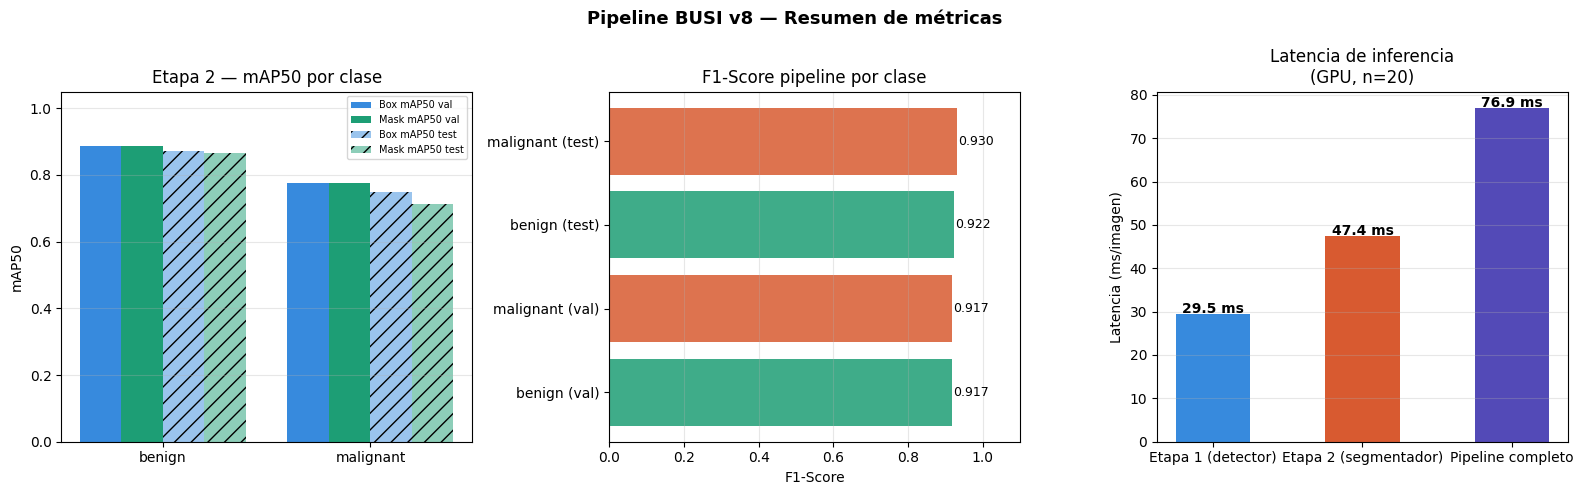


Gráfico guardado en /content/metricas_v8.png


In [13]:
# =============================================================================
# RESUMEN DE MÉTRICAS COMPLETAS — Pipeline v8
# mAP, F1-Score, Precision, Recall, Latencia
# =============================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Métricas YOLO nativas ──────────────────────────────────────────────────
# (requiere que m_s1_val, m_s1_test, m_s2_val, m_s2_test ya estén calculados)

def f1(p, r): return 2*p*r/(p+r) if (p+r)>0 else 0.0

names_s1 = {0:"lesion", 1:"normal"}
names_s2 = {0:"benign", 1:"malignant"}

rows = []

# Etapa 1 val
for ci, ap50, ap, p, r in zip(
    m_s1_val.box.ap_class_index.tolist(),
    m_s1_val.box.ap50.tolist(),
    m_s1_val.box.ap.tolist(),
    m_s1_val.box.p.tolist(),
    m_s1_val.box.r.tolist(),
):
    rows.append({"Etapa":"S1","Split":"Val","Clase":names_s1.get(ci,ci),
                 "Precision":p,"Recall":r,"F1":f1(p,r),"mAP50":ap50,"mAP50-95":ap,"Mask_mAP50":"-"})
# Etapa 1 test
for ci, ap50, ap, p, r in zip(
    m_s1_test.box.ap_class_index.tolist(),
    m_s1_test.box.ap50.tolist(),
    m_s1_test.box.ap.tolist(),
    m_s1_test.box.p.tolist(),
    m_s1_test.box.r.tolist(),
):
    rows.append({"Etapa":"S1","Split":"Test","Clase":names_s1.get(ci,ci),
                 "Precision":p,"Recall":r,"F1":f1(p,r),"mAP50":ap50,"mAP50-95":ap,"Mask_mAP50":"-"})

# Etapa 2 val
for ci, ap50, ap, map50m, p, r in zip(
    m_s2_val.seg.ap_class_index.tolist(),
    m_s2_val.box.ap50.tolist(),
    m_s2_val.box.ap.tolist(),
    m_s2_val.seg.ap50.tolist(),
    m_s2_val.seg.p.tolist(),
    m_s2_val.seg.r.tolist(),
):
    rows.append({"Etapa":"S2","Split":"Val","Clase":names_s2.get(ci,ci),
                 "Precision":p,"Recall":r,"F1":f1(p,r),"mAP50":ap50,"mAP50-95":ap,"Mask_mAP50":map50m})
# Etapa 2 test
for ci, ap50, ap, map50m, p, r in zip(
    m_s2_test.seg.ap_class_index.tolist(),
    m_s2_test.box.ap50.tolist(),
    m_s2_test.box.ap.tolist(),
    m_s2_test.seg.ap50.tolist(),
    m_s2_test.seg.p.tolist(),
    m_s2_test.seg.r.tolist(),
):
    rows.append({"Etapa":"S2","Split":"Test","Clase":names_s2.get(ci,ci),
                 "Precision":p,"Recall":r,"F1":f1(p,r),"mAP50":ap50,"mAP50-95":ap,"Mask_mAP50":map50m})

df_metrics = pd.DataFrame(rows)
df_fmt = df_metrics.copy()
for col in ["Precision","Recall","F1","mAP50","mAP50-95"]:
    df_fmt[col] = df_fmt[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
df_fmt["Mask_mAP50"] = df_fmt["Mask_mAP50"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print("=" * 75)
print("TABLA DE MÉTRICAS COMPLETAS — Pipeline BUSI v8")
print("=" * 75)
print(df_fmt.to_string(index=False))

# ── 2. Métricas del pipeline 3 clases ────────────────────────────────────────
print("\n" + "=" * 75)
print("MÉTRICAS PIPELINE COMPLETO (conf_s1=0.25, conf_s2=0.15)")
print("=" * 75)
for split_name, stats in [("Val", stats_val), ("Test", stats_test)]:
    print(f"\n  {split_name}:")
    for cls in ["benign","malignant"]:
        d = stats[cls]; tot = d["total"]
        p_val = d["detected"]/(d["detected"]+(d.get("as_malignant",0) or d.get("as_benign",0))) if d["detected"]>0 else 0.0
        r_val = d["detected"]/tot if tot else 0.0
        print(f"    {cls:10s}: Sensibilidad={r_val:.4f}  F1≈{f1(p_val, r_val):.4f}  "
              f"(detectadas={d['detected']}/{tot})")
    d = stats["normal"]; tot = d["total"]
    spec = d["clean"]/tot if tot else 0.0
    print(f"    {'normal':10s}: Especificidad={spec:.4f}  FP={d['fp']}/{tot}")

# ── 3. Latencia de inferencia ─────────────────────────────────────────────────
print("\n" + "=" * 75)
print("LATENCIA DE INFERENCIA (promedio sobre 20 imágenes de val)")
print("=" * 75)
sample_imgs = list((OUTPUT_EVAL/"images"/"val").glob("*.png"))[:20]
if not sample_imgs:
    sample_imgs = list((OUTPUT_EVAL/"images"/"val").glob("*.jpg"))[:20]

t_s1_total, t_s2_total, t_pipe_total = 0.0, 0.0, 0.0
n = len(sample_imgs)
for img_path in sample_imgs:
    # Solo S1
    t0 = time.perf_counter()
    r1 = model_s1(str(img_path), conf=CONF_S1, verbose=False)
    t_s1_total += time.perf_counter() - t0
    has_lesion = any(
        int(b.cls.item()) == 0 for r in r1 for b in (r.boxes if r.boxes else [])
        if hasattr(b, "cls")
    )
    # S1 + S2 completo
    t0 = time.perf_counter()
    out = predict_two_stage(img_path, model_s1, model_s2,
                            conf_s1=CONF_S1, conf_s2=CONF_S2)
    t_pipe_total += time.perf_counter() - t0
    if out["has_lesion"] and out["result_seg"] is not None:
        t_s2_total += 0.0  # ya incluido en t_pipe

lat_s1   = t_s1_total   / n * 1000
lat_pipe = t_pipe_total / n * 1000
lat_s2   = lat_pipe - lat_s1

print(f"  Imágenes evaluadas : {n}")
print(f"  Etapa 1 (detector) : {lat_s1:.1f} ms/imagen")
print(f"  Etapa 2 (seg)      : {lat_s2:.1f} ms/imagen  (solo cuando hay lesión)")
print(f"  Pipeline completo  : {lat_pipe:.1f} ms/imagen")
print(f"  FPS estimado       : {1000/lat_pipe:.1f}")

# ── 4. Gráfico resumen ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# Panel 1: mAP50 por clase y split
ax1 = fig.add_subplot(gs[0])
classes_s2 = ["benign","malignant"]
map50_val  = [r["mAP50"]  for r in rows if r["Etapa"]=="S2" and r["Split"]=="Val"]
mask50_val = [r["Mask_mAP50"] for r in rows if r["Etapa"]=="S2" and r["Split"]=="Val"]
map50_test = [r["mAP50"]  for r in rows if r["Etapa"]=="S2" and r["Split"]=="Test"]
mask50_test= [r["Mask_mAP50"] for r in rows if r["Etapa"]=="S2" and r["Split"]=="Test"]
x = np.arange(len(classes_s2)); w = 0.2
ax1.bar(x-1.5*w, map50_val,   w, label="Box mAP50 val",  color="#378ADD")
ax1.bar(x-0.5*w, mask50_val,  w, label="Mask mAP50 val", color="#1D9E75")
ax1.bar(x+0.5*w, map50_test,  w, label="Box mAP50 test", color="#378ADD", alpha=0.5, hatch="//")
ax1.bar(x+1.5*w, mask50_test, w, label="Mask mAP50 test",color="#1D9E75", alpha=0.5, hatch="//")
ax1.set_xticks(x); ax1.set_xticklabels(classes_s2)
ax1.set_ylim(0, 1.05); ax1.set_ylabel("mAP50")
ax1.set_title("Etapa 2 — mAP50 por clase")
ax1.legend(fontsize=7); ax1.grid(axis="y", alpha=0.3)

# Panel 2: F1 por clase (pipeline)
ax2 = fig.add_subplot(gs[1])
pipeline_classes = ["benign (val)","malignant (val)","benign (test)","malignant (test)"]
pipeline_f1 = []
for split_name, stats in [("val", stats_val), ("test", stats_test)]:
    for cls in ["benign","malignant"]:
        d = stats[cls]; tot = d["total"]
        tp = d["detected"]
        fp = d.get("as_malignant",0) or d.get("as_benign",0)
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/tot if tot else 0.0
        pipeline_f1.append(f1(prec,rec))
colors_f1 = ["#1D9E75","#D85A30","#1D9E75","#D85A30"]
bars = ax2.barh(pipeline_classes, pipeline_f1, color=colors_f1, alpha=0.85)
for bar, val in zip(bars, pipeline_f1):
    ax2.text(val+0.005, bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)
ax2.set_xlim(0, 1.1); ax2.set_xlabel("F1-Score")
ax2.set_title("F1-Score pipeline por clase")
ax2.grid(axis="x", alpha=0.3)

# Panel 3: latencia
ax3 = fig.add_subplot(gs[2])
lat_labels = ["Etapa 1 (detector)", "Etapa 2 (segmentador)", "Pipeline completo"]
lat_vals   = [lat_s1, lat_s2, lat_pipe]
lat_colors = ["#378ADD", "#D85A30", "#534AB7"]
bars3 = ax3.bar(lat_labels, lat_vals, color=lat_colors, width=0.5)
for bar, val in zip(bars3, lat_vals):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.3,
             f"{val:.1f} ms", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylabel("Latencia (ms/imagen)")
ax3.set_title(f"Latencia de inferencia\n(GPU, n={n})")
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("Pipeline BUSI v8 — Resumen de métricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/metricas_v8.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGráfico guardado en /content/metricas_v8.png")


## Sweep de umbrales (opcional)


In [14]:
import pandas as pd
print(">>> Sweep Val")
df_val = sweep_pipeline(
    OUTPUT_EVAL, model_s1, model_s2, split="val",
    conf_s1_values=(0.20, 0.25, 0.30, 0.35, 0.40),
    conf_s2_values=(0.10, 0.15, 0.20, 0.25),
)
display(df_val.head(8))


>>> Sweep Val

Evaluación pipeline 2-etapas | split=val | conf_s1=0.2 | conf_s2=0.1
benign     → total= 62 | detectadas= 56 | perdidas=  2 | como malignant=4 | sensibilidad=0.9032
malignant  → total= 26 | detectadas= 22 | perdidas=  4 | como benign=0 | sensibilidad=0.8462
normal     → total= 24 | limpias= 23 | FP=  1 | especificidad=0.9583

Evaluación pipeline 2-etapas | split=val | conf_s1=0.2 | conf_s2=0.15
benign     → total= 62 | detectadas= 56 | perdidas=  2 | como malignant=4 | sensibilidad=0.9032
malignant  → total= 26 | detectadas= 22 | perdidas=  4 | como benign=0 | sensibilidad=0.8462
normal     → total= 24 | limpias= 23 | FP=  1 | especificidad=0.9583

Evaluación pipeline 2-etapas | split=val | conf_s1=0.2 | conf_s2=0.2
benign     → total= 62 | detectadas= 56 | perdidas=  3 | como malignant=3 | sensibilidad=0.9032
malignant  → total= 26 | detectadas= 22 | perdidas=  4 | como benign=0 | sensibilidad=0.8462
normal     → total= 24 | limpias= 23 | FP=  1 | especificidad=0.9583



,conf_s1,conf_s2,benign_sens,malignant_sens,normal_spec,normal_fp,score
0,0.4,0.25,0.887097,0.846154,1.000000,0,0.900496
1,0.4,0.20,0.887097,0.846154,1.000000,0,0.900496
2,0.4,0.15,0.887097,0.846154,1.000000,0,0.900496
3,0.4,0.10,0.887097,0.846154,1.000000,0,0.900496
4,0.2,0.25,0.903226,0.846154,0.958333,1,0.891222
5,0.2,0.20,0.903226,0.846154,0.958333,1,0.891222
6,0.2,0.15,0.903226,0.846154,0.958333,1,0.891222
7,0.2,0.10,0.903226,0.846154,0.958333,1,0.891222


## Visualización de predicciones


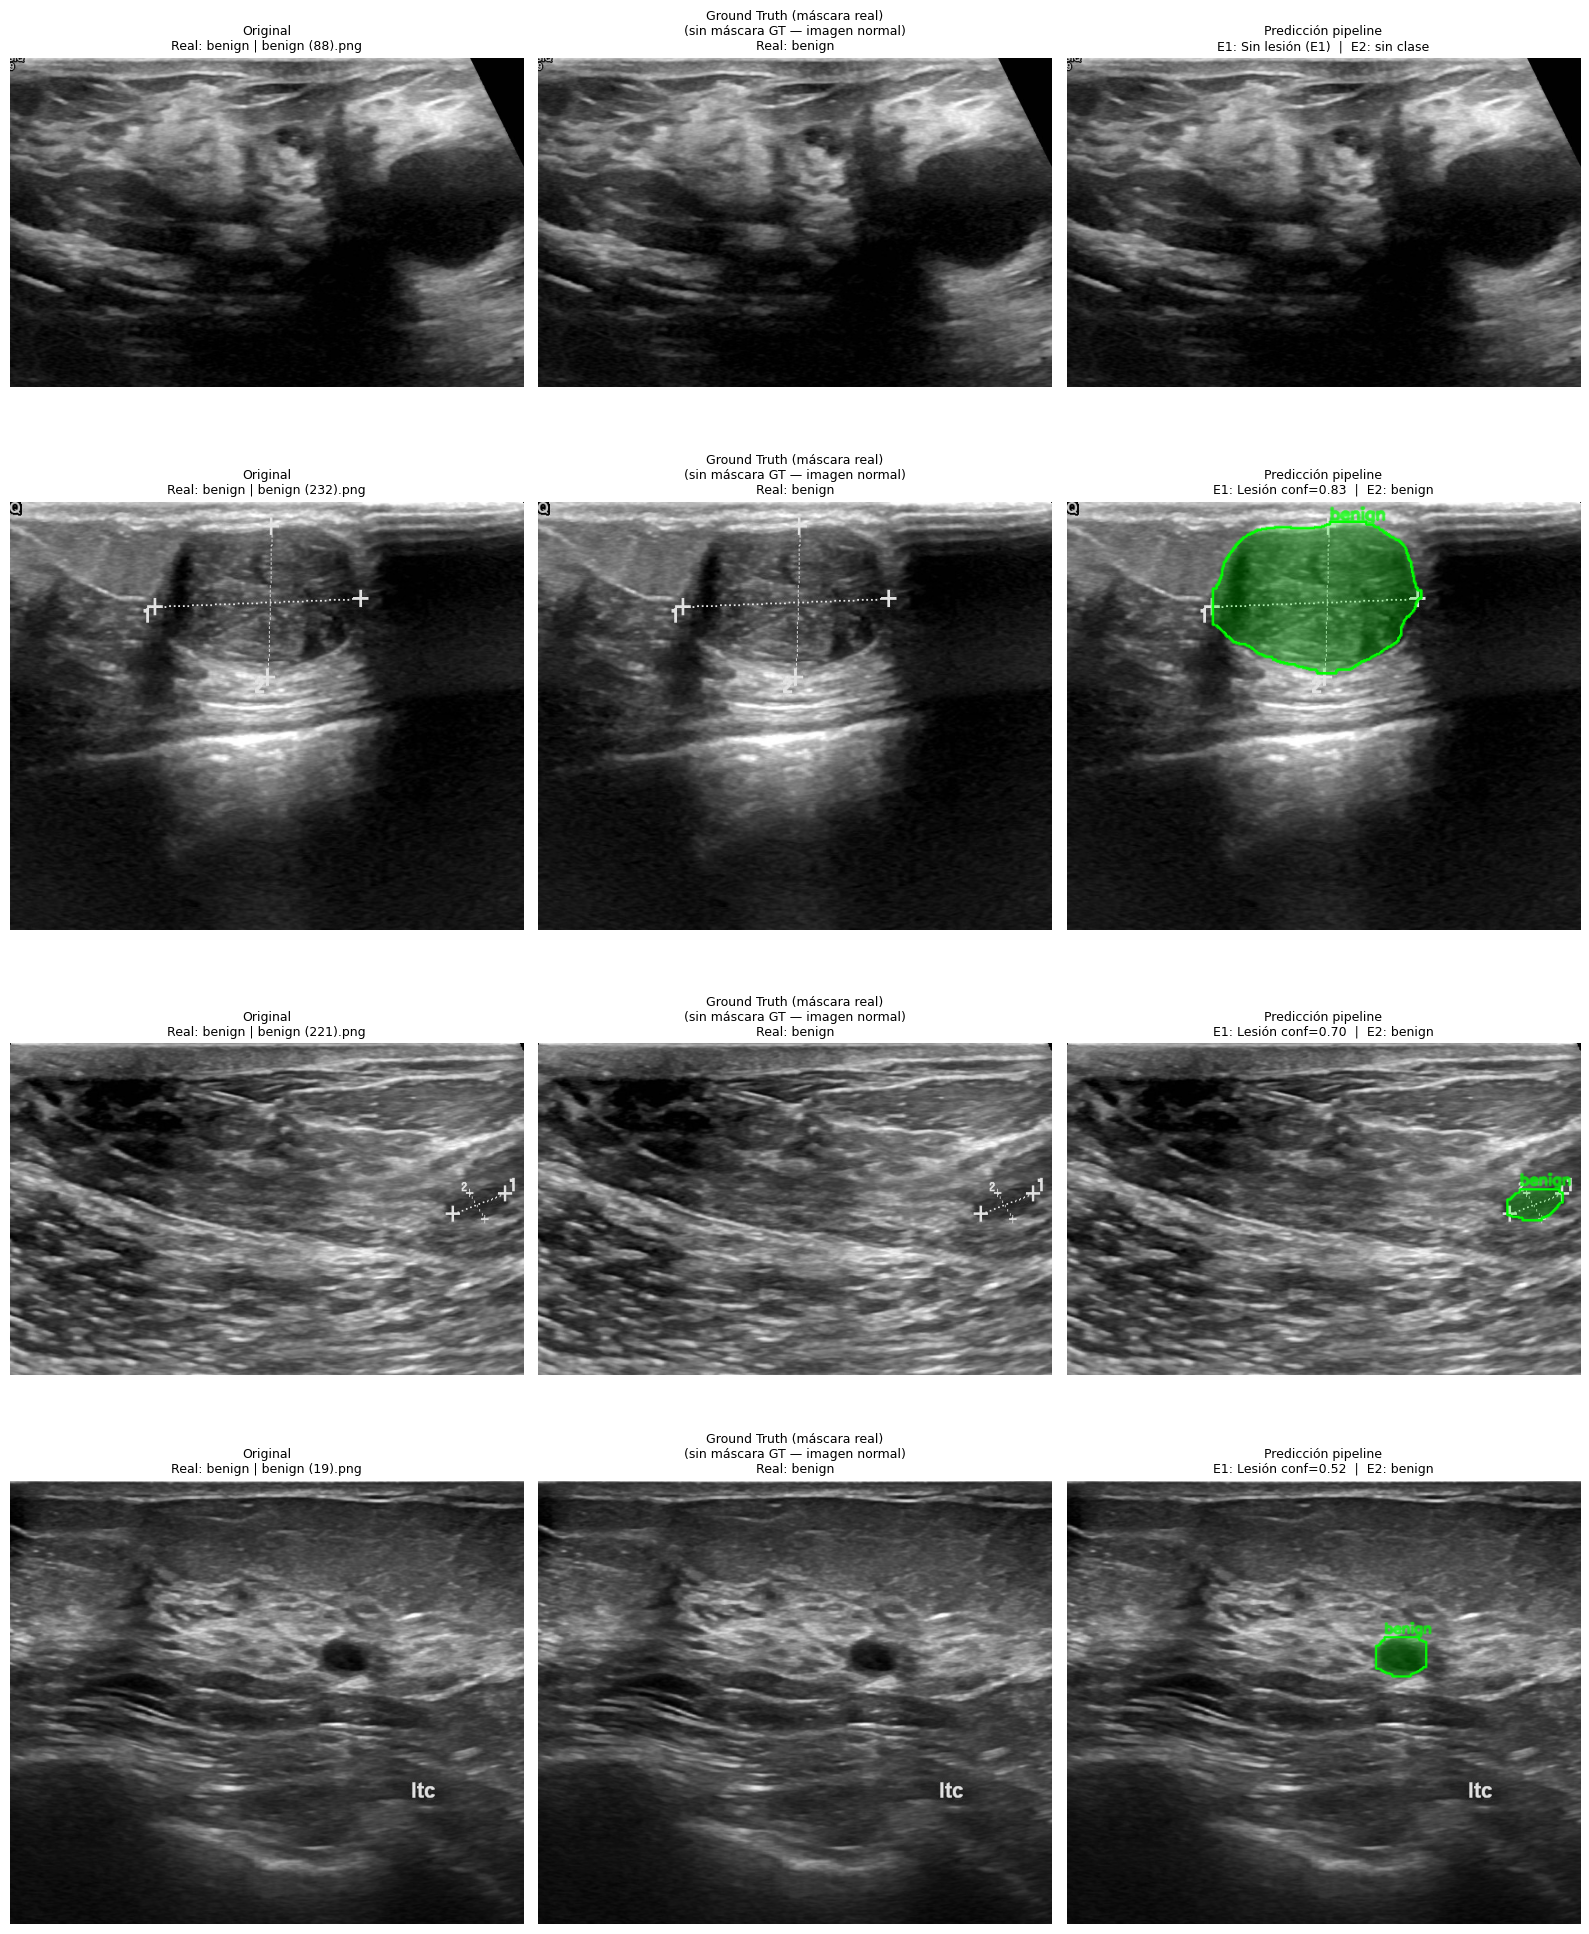

In [15]:
show_pipeline_predictions(
    OUTPUT_EVAL, model_s1, model_s2,
    split="val", classes="benign", n=4,
    conf_s1=CONF_S1, conf_s2=CONF_S2,
    seg_root=OUTPUT_SEG,
)


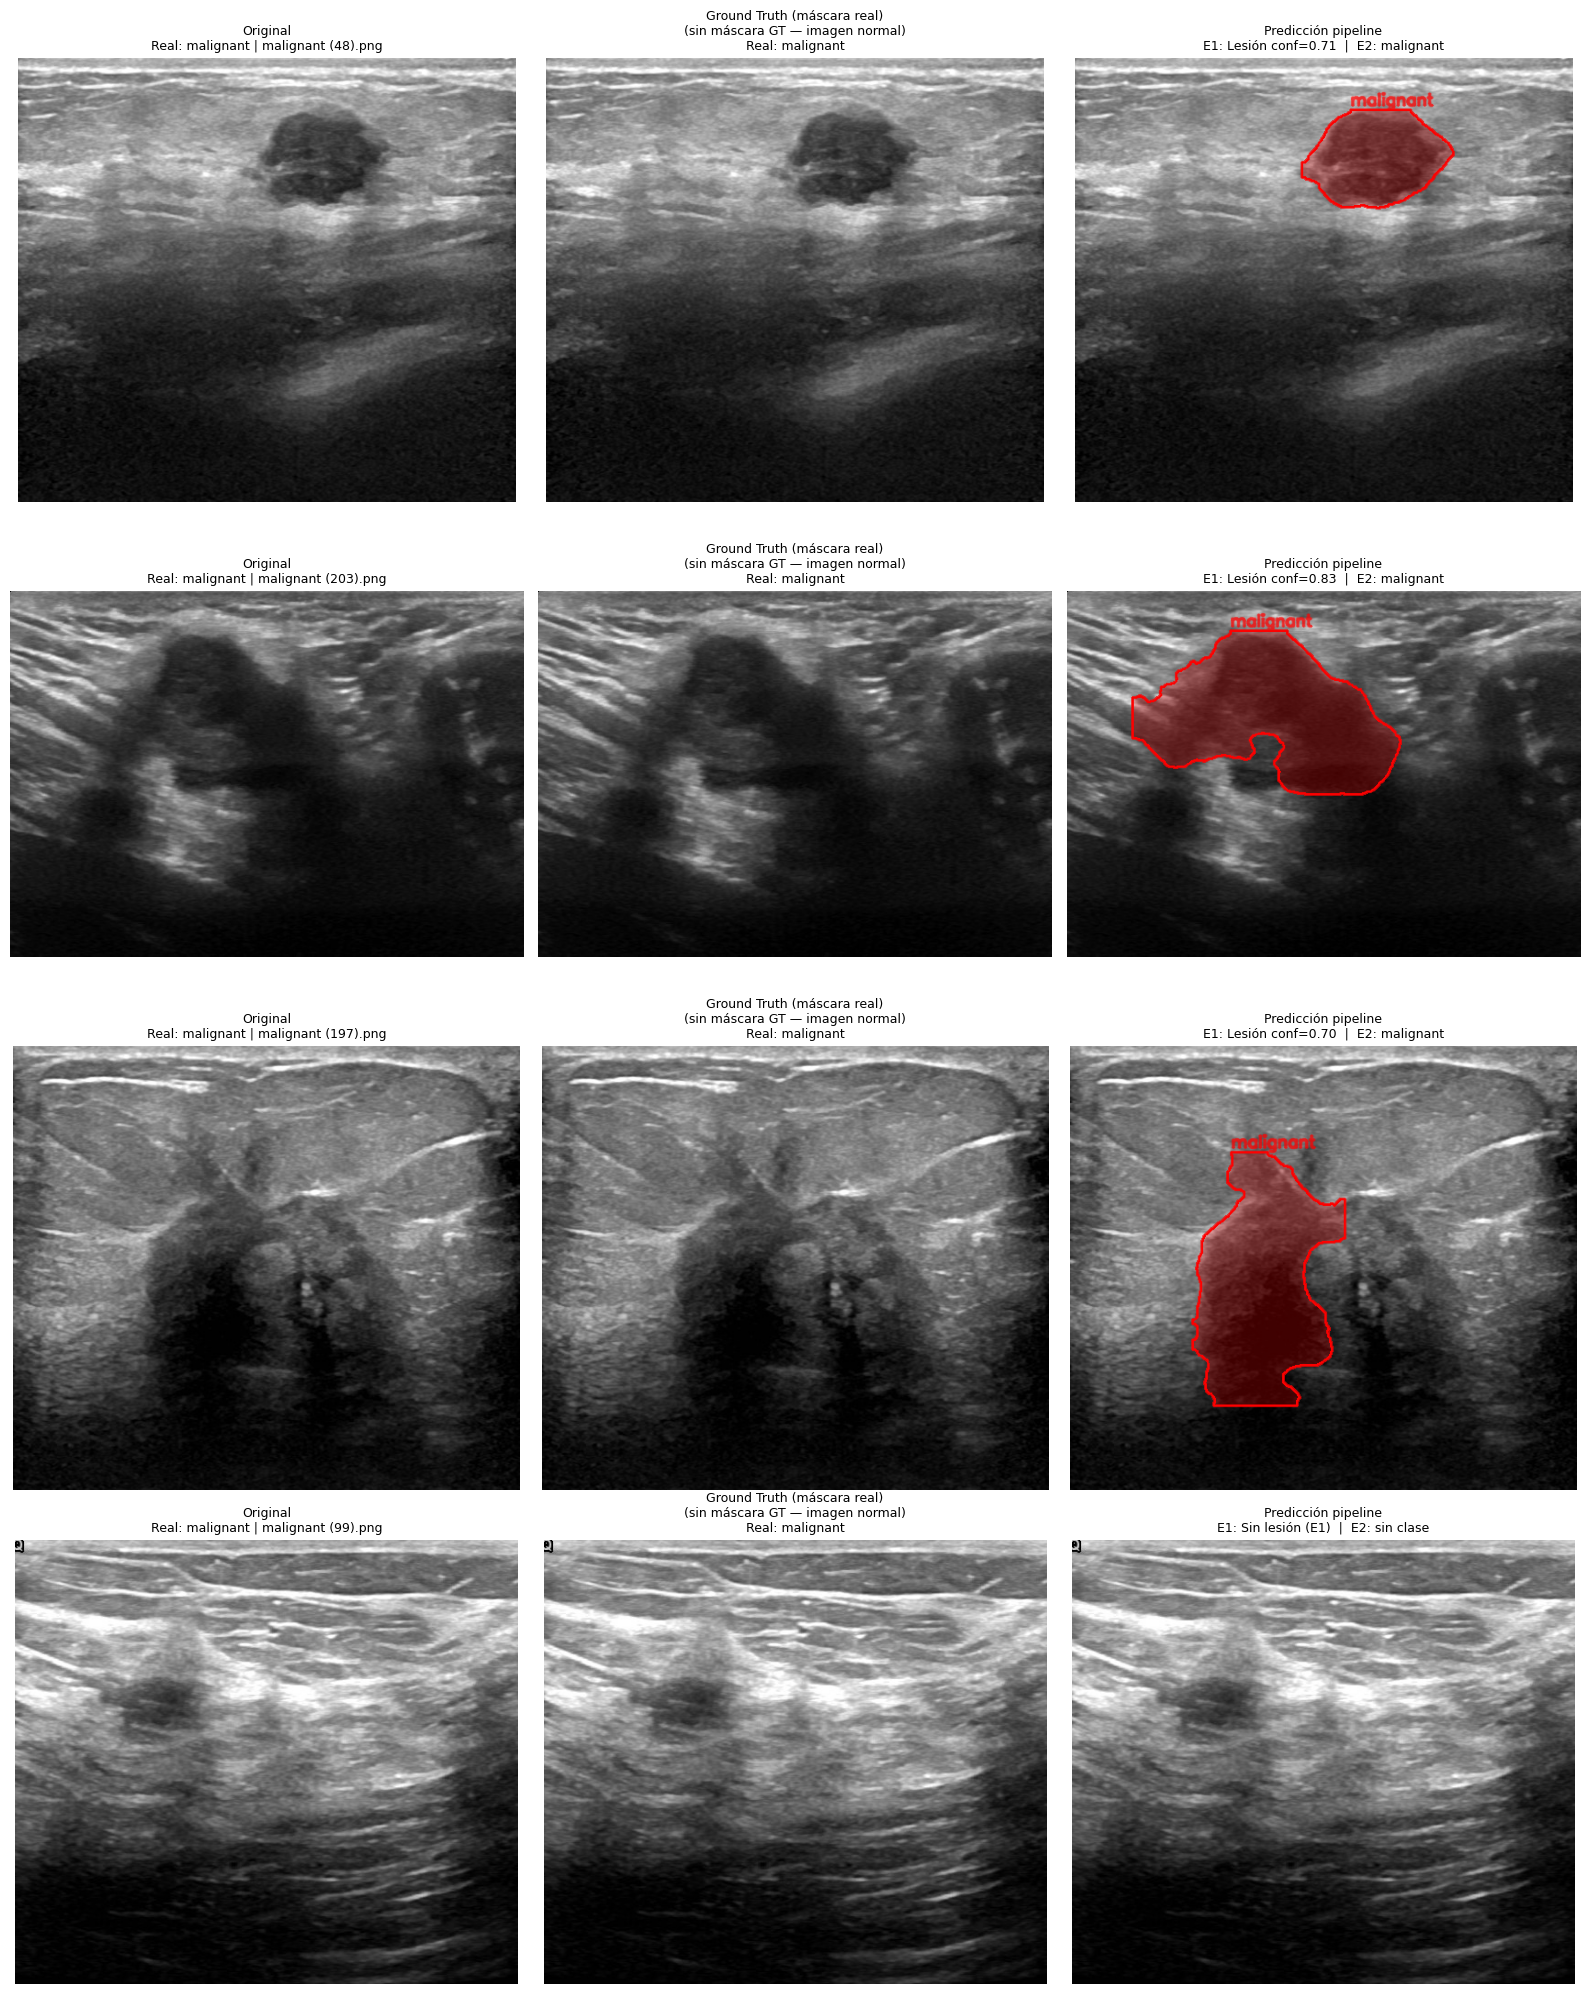

In [16]:
show_pipeline_predictions(
    OUTPUT_EVAL, model_s1, model_s2,
    split="val", classes="malignant", n=4,
    conf_s1=CONF_S1, conf_s2=CONF_S2,
    seg_root=OUTPUT_SEG,
)


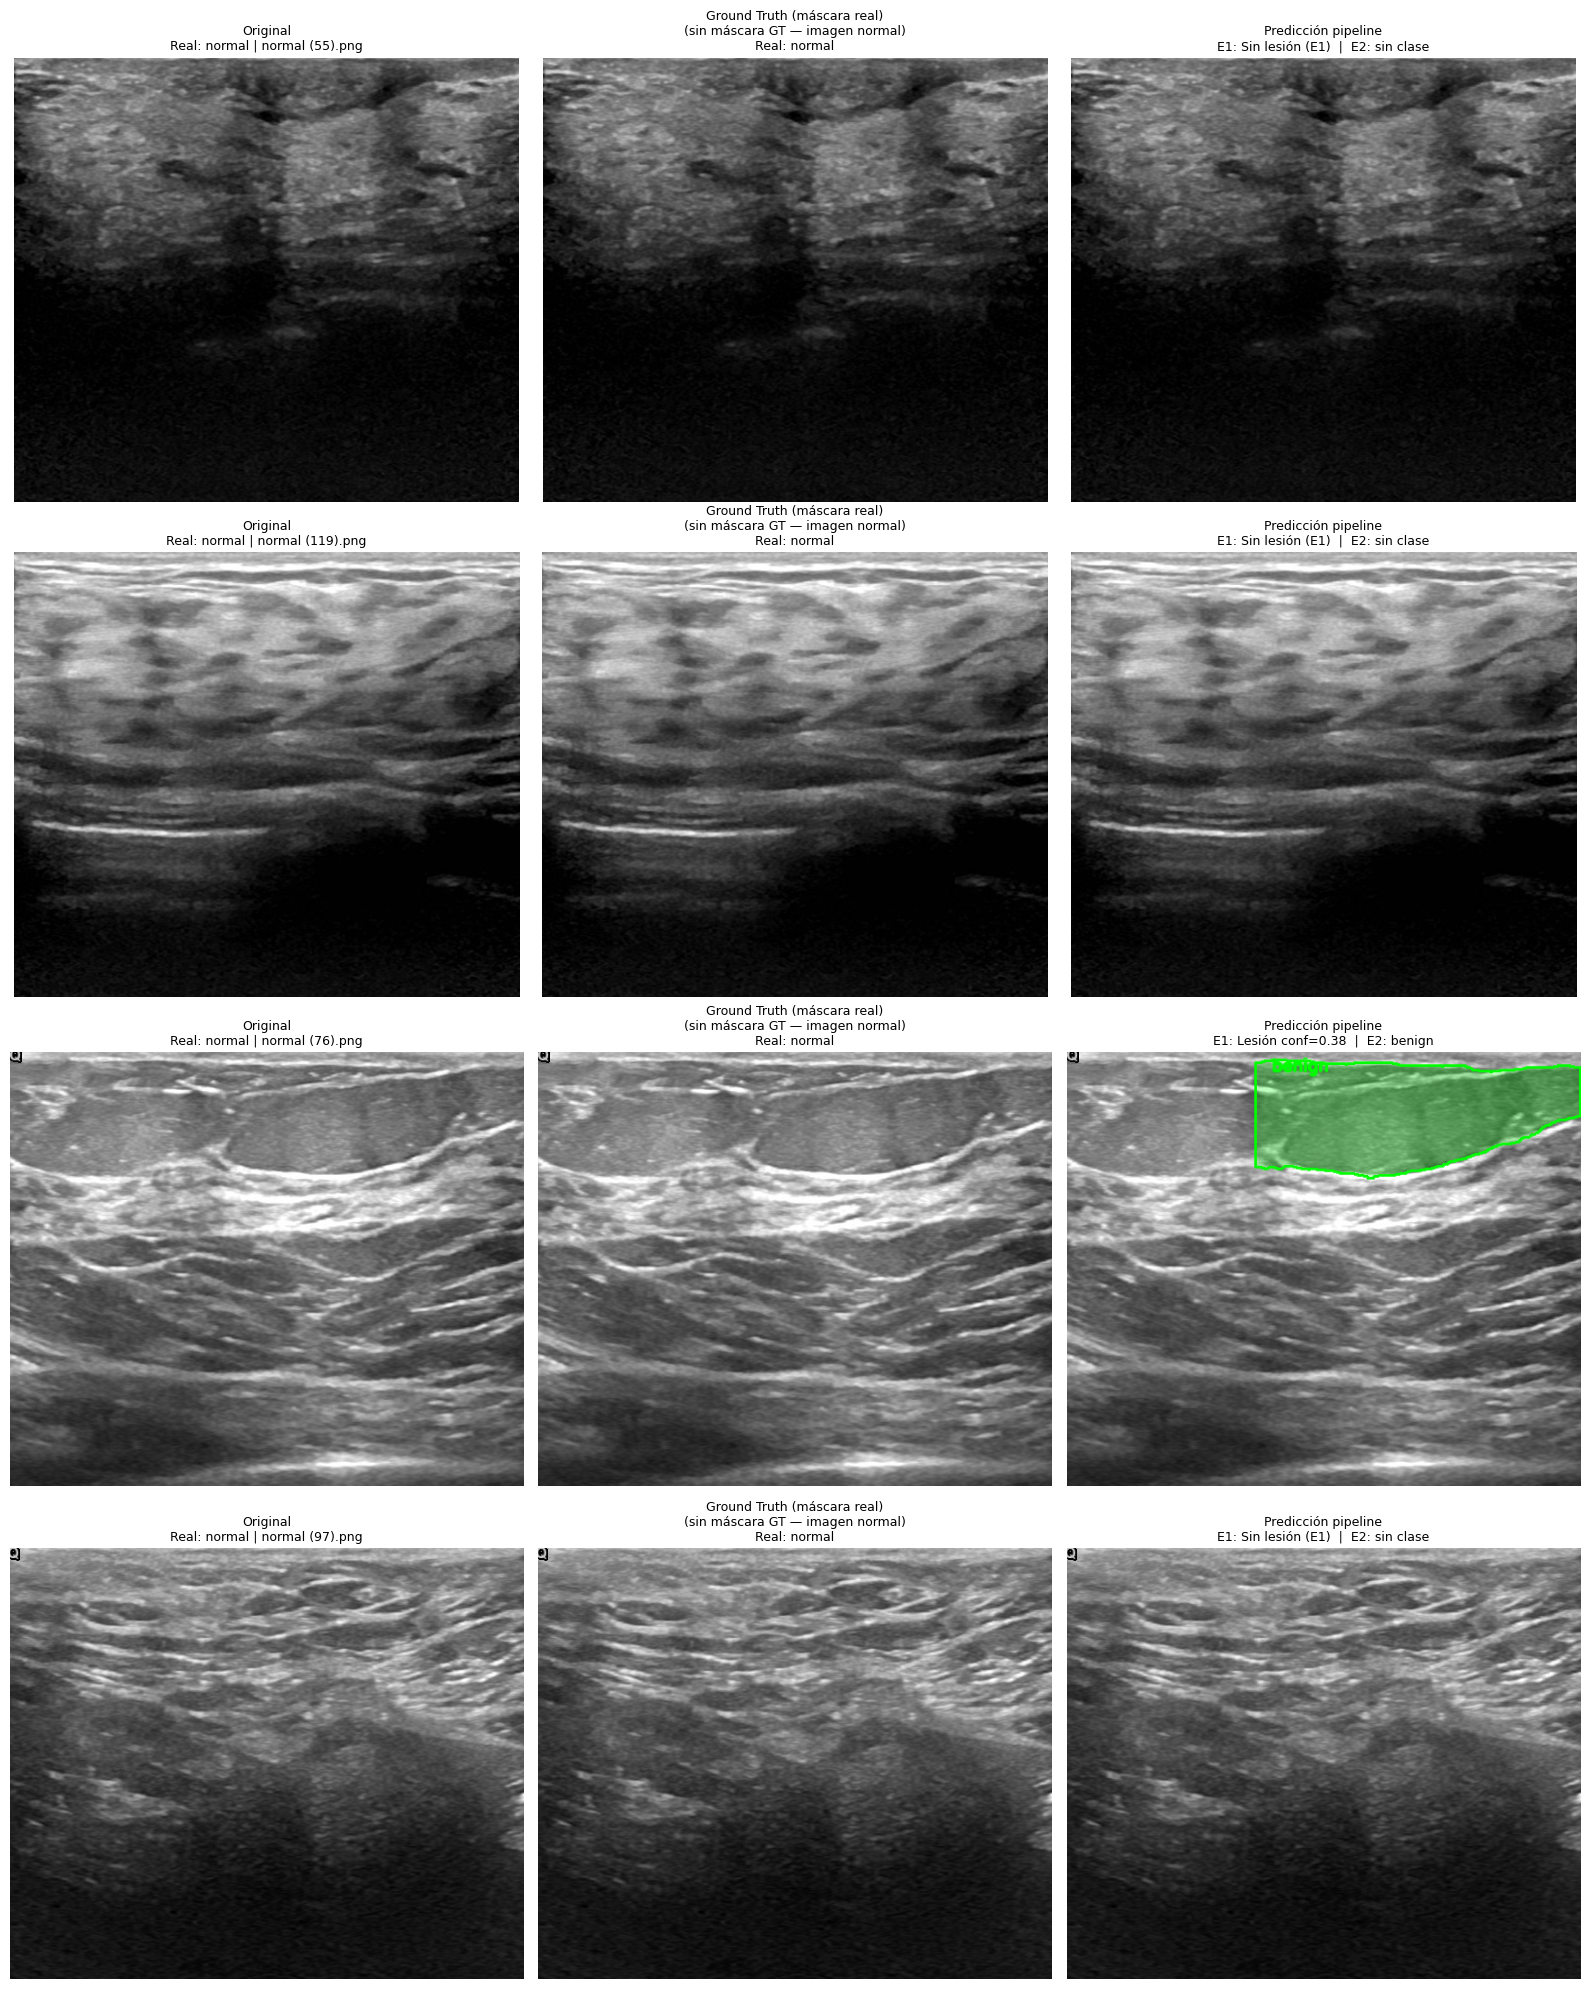

In [17]:
show_pipeline_predictions(
    OUTPUT_EVAL, model_s1, model_s2,
    split="val", classes="normal", n=4,
    conf_s1=CONF_S1, conf_s2=CONF_S2,
    seg_root=OUTPUT_SEG,
)


## Inferencia sobre imagen individual


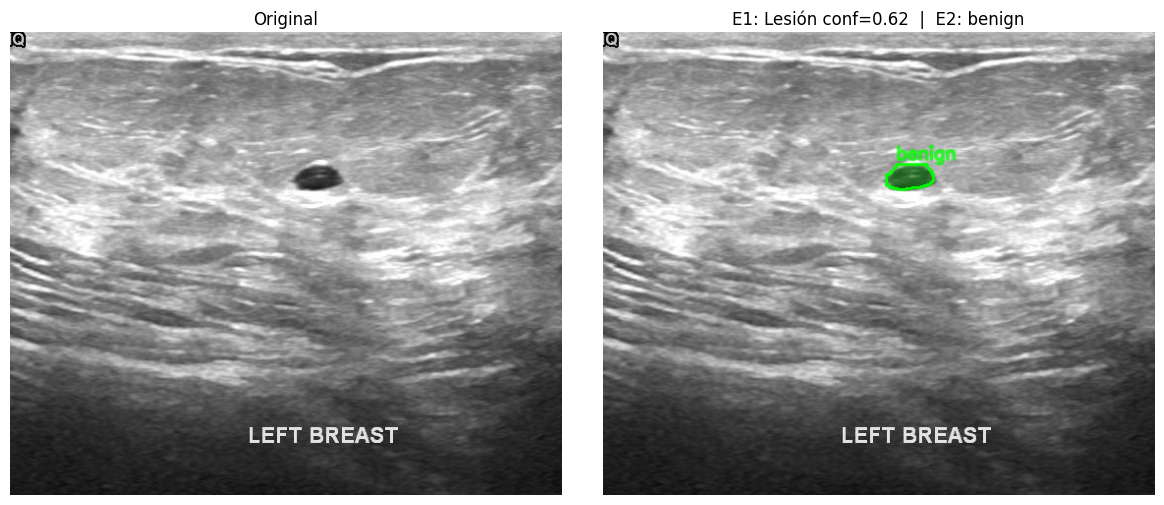

has_lesion   : True
stage1_conf  : 0.6211904287338257
final_classes: ['benign']


In [18]:
import matplotlib.pyplot as plt

IMG_PATH = Path("/content/breast-ultrasound-images-dataset/benign/benign (1).png")

out = predict_two_stage(IMG_PATH, model_s1, model_s2,
                        conf_s1=CONF_S1, conf_s2=CONF_S2)
img_rgb  = load_image_rgb(IMG_PATH)
pred_img = draw_seg_overlay(img_rgb, out["result_seg"])

s1_txt = f"Lesión conf={out['stage1_conf']:.2f}" if out["has_lesion"] else "Sin lesión"
s2_txt = ", ".join(out["final_classes"]) if out["final_classes"] else "—"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb);  axes[0].set_title("Original");                        axes[0].axis("off")
axes[1].imshow(pred_img); axes[1].set_title(f"E1: {s1_txt}  |  E2: {s2_txt}"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"has_lesion   : {out['has_lesion']}")
print(f"stage1_conf  : {out['stage1_conf']}")
print(f"final_classes: {out['final_classes']}")
